In [59]:
# import libraries
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

In [60]:
# prepare data
madrid_2017 = pd.read_csv('data/madrid_2017.csv')
stations = pd.read_csv('data/stations.csv')


In [61]:

madrid_2017.head()

,date,BEN,CH4,CO,EBE,NMHC,NO,NO_2,NOx,O_3,PM10,PM25,SO_2,TCH,TOL,station
0,2017-06-01 01:00:00,NaN,NaN,0.3,NaN,NaN,4.0,38.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,28079004
1,2017-06-01 01:00:00,0.6,NaN,0.3,0.4,0.08,3.0,39.0,NaN,71.0,22.0,9.0,7.0,1.4,2.9,28079008
2,2017-06-01 01:00:00,0.2,NaN,NaN,0.1,NaN,1.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN,0.9,28079011
3,2017-06-01 01:00:00,NaN,NaN,0.2,NaN,NaN,1.0,9.0,NaN,91.0,NaN,NaN,NaN,NaN,NaN,28079016
4,2017-06-01 01:00:00,NaN,NaN,NaN,NaN,NaN,1.0,19.0,NaN,69.0,NaN,NaN,2.0,NaN,NaN,28079017


In [62]:
stations.head()

,id,name,address,lon,lat,elevation
0,28079004,Pza. de España,Plaza de España,-3.712247,40.423853,635
1,28079008,Escuelas Aguirre,Entre C/ Alcalá y C/ O’ Donell,-3.682319,40.421564,670
2,28079011,Avda. Ramón y Cajal,Avda. Ramón y Cajal esq. C/ Príncipe de Vergara,-3.677356,40.451475,708
3,28079016,Arturo Soria,C/ Arturo Soria esq. C/ Vizconde de los Asilos,-3.639233,40.440047,693
4,28079017,Villaverde,C/. Juan Peñalver,-3.713322,40.347139,604


In [63]:
# format data
madrid_2017['date'] = pd.to_datetime(madrid_2017['date'])

In [64]:
# calculate mean NO_2 for each station
station_mean = madrid_2017.groupby('station')['NO_2'].mean().reset_index()
station_mean.head()

,station,NO_2
0,28079004,49.428080
1,28079008,61.867318
2,28079011,45.717346
3,28079016,41.710264
4,28079017,48.607767


In [65]:
# merge 2017 data with station metadata
madrid_2017_station = station_mean.merge(stations, left_on='station', right_on='id')
madrid_2017_station.head()

,station,NO_2,id,name,address,lon,lat,elevation
0,28079004,49.428080,28079004,Pza. de España,Plaza de España,-3.712247,40.423853,635
1,28079008,61.867318,28079008,Escuelas Aguirre,Entre C/ Alcalá y C/ O’ Donell,-3.682319,40.421564,670
2,28079011,45.717346,28079011,Avda. Ramón y Cajal,Avda. Ramón y Cajal esq. C/ Príncipe de Vergara,-3.677356,40.451475,708
3,28079016,41.710264,28079016,Arturo Soria,C/ Arturo Soria esq. C/ Vizconde de los Asilos,-3.639233,40.440047,693
4,28079017,48.607767,28079017,Villaverde,C/. Juan Peñalver,-3.713322,40.347139,604


In [66]:
fig = px.scatter_map(
    madrid_2017_station,
    lat="lat",
    lon="lon",
    color="NO_2",
    color_continuous_scale="Blues",
    range_color=[0, 75],
    hover_name="name",
    size="NO_2",
    size_max=15,
    hover_data={
        "lat": False,
        "lon": False,
        "NO_2": ":.2f",
    },
    zoom=10,
    center={"lat": 40.435, "lon": -3.69},
    map_style="carto-positron",
    title="<b>Madrid Air Quality</b><br><sup>Continuous NO₂ Concentration (µg/m³)</sup>",
)

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0},
                  coloraxis_colorbar=dict(title="NO₂ (µg/m³)",yanchor="top",
                                          y=1, ticks="outside",
                                          thickness=15,  len=0.4),
    font=dict(family="Arial", size=12))
fig.show()

In [67]:
MONTH_LABELS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# build monthly city-wide averages from the hourly data
madrid_2017['month'] = madrid_2017['date'].dt.month
monthly = (
    madrid_2017.groupby('month')[['NO_2', 'O_3']]
    .mean()
    .reset_index()
)

def savefig(fname):
    plt.savefig(fname, dpi=150, bbox_inches='tight')

Policy 4/4 – NO₂ vs O₃ annual trend 2001–2018


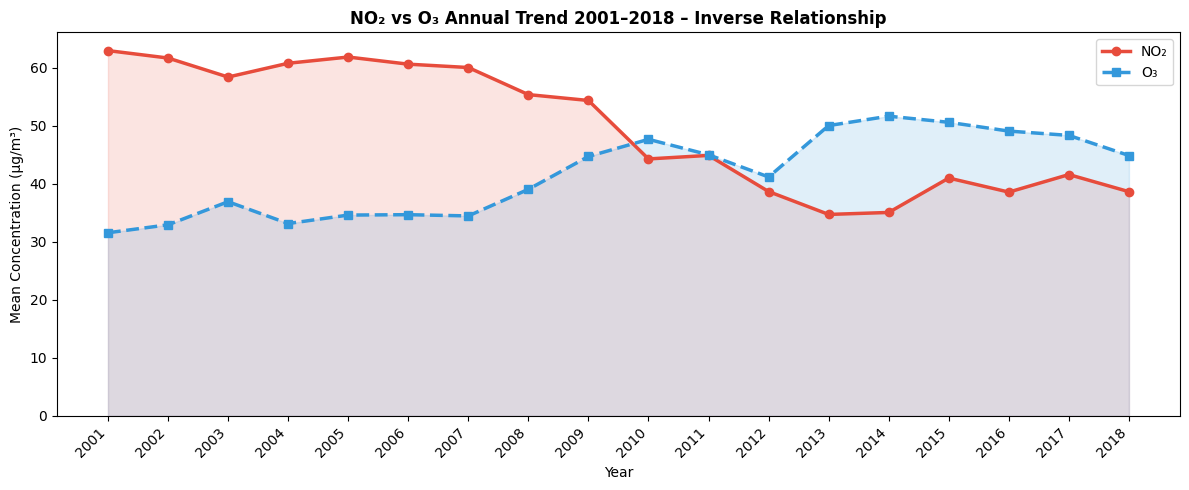

In [68]:
# Q4. NO₂ vs O₃ long-term annual trend (2001–2018)
print("Policy 4/4 – NO₂ vs O₃ annual trend 2001–2018")

years = range(2001, 2019)
records = []
for yr in years:
    df = pd.read_csv(f"data/madrid_{yr}.csv")
    records.append({
        "year": yr,
        "NO_2": df["NO_2"].mean(),
        "O_3":  df["O_3"].mean(),
    })
annual = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(annual["year"], annual["NO_2"], color="#e74c3c", linewidth=2.5,
        marker="o", label="NO₂")
ax.fill_between(annual["year"], annual["NO_2"], alpha=0.15, color="#e74c3c")
ax.plot(annual["year"], annual["O_3"],  color="#3498db", linewidth=2.5,
        marker="s", linestyle="--", label="O₃")
ax.fill_between(annual["year"], annual["O_3"], alpha=0.15, color="#3498db")
ax.set_ylim(bottom=0)
ax.set_xticks(list(years))
ax.set_xticklabels(list(years), rotation=45, ha="right")
ax.set_ylabel("Mean Concentration (µg/m³)")
ax.set_xlabel("Year")
ax.legend(loc="upper right", fontsize=10)
ax.set_title("NO₂ vs O₃ Annual Trend 2001–2018 – Inverse Relationship",
             fontsize=12, weight="bold")
plt.tight_layout()
savefig("Q4_pollutants_2001_2018_trend.png")